# Planners Comparison Study

This notebook demonstrates how to conduct a comprehensive comparison of different POMDP planning algorithms using the LocalSimulationsAPI. We'll compare POMCPOW and PFT-DPW planners on Push POMDP and Light-Dark POMDP environments, showcasing how to evaluate algorithm performance across different problem domains.

## Overview

**Planning Algorithms Tested:**
- **POMCPOW**: Monte Carlo Tree Search with double progressive widening
- **PFT-DPW**: Progressive Function Transfer with Double Progressive Widening

**Environments Tested:**
- **Push POMDP**: Object manipulation with discrete actions and continuous observations
- **Light-Dark POMDP**: Navigation with discrete actions and position-dependent observation noise

**Key Features Demonstrated:**
- Environment configuration using EnvironmentConfigsAPI
- Pre-built action samplers from utils module for different action spaces
- Statistical analysis with confidence intervals
- Multi-environment, multi-algorithm evaluation
- Result visualization

## Setup and Imports

In [3]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Core POMDPPlanners imports
from POMDPPlanners.configs.environment_configs import EnvironmentConfigsAPI
from POMDPPlanners.planners.mcts_planners.pomcpow import POMCPOW
from POMDPPlanners.planners.mcts_planners.pft_dpw import PFT_DPW
from POMDPPlanners.simulations.simulation_apis.local_simulations_api import LocalSimulationsAPI
from POMDPPlanners.core.simulation import EnvironmentRunParams
from POMDPPlanners.utils.action_samplers import DiscreteActionSampler

env_config = EnvironmentConfigsAPI(discount_factor=0.95, debug=False)

## Push POMDP Configuration

Environment, belief, action sampler, and planners for the Push POMDP domain.

In [4]:
# Environment and belief
push_env, push_belief = env_config.push_pomdp_config(n_particles=200)
print(f"Created Push POMDP environment: {push_env.__class__.__name__}")

# Action sampler — discrete actions ["up", "down", "right", "left"]
push_action_sampler = DiscreteActionSampler(actions=push_env.get_actions())
print(f"Discrete action sampler: {push_env.get_actions()}")

# Planners
# exploration_constant = (max_reward - min_reward) * depth = (100.0 - (-12.73)) * 10 ≈ 1127.28
push_planners = [
    POMCPOW(
        environment=push_env,
        discount_factor=0.95,
        depth=10,
        exploration_constant=1127.28,
        k_o=10,
        k_a=4,
        alpha_o=0.01,
        alpha_a=0.01,
        action_sampler=push_action_sampler,
        n_simulations=2000,
        name="POMCPOW_Push"
    ),
    PFT_DPW(
        environment=push_env,
        discount_factor=0.95,
        depth=10,
        name="PFT_DPW_Push",
        action_sampler=push_action_sampler,
        k_a=10,
        alpha_a=0.01,
        k_o=10,
        alpha_o=0.01,
        exploration_constant=1100,
        n_simulations=2000
    )
]

2026-02-25 12:49:24,474 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/core/environment.py:296 - Initializing PushPOMDP environment with discount factor 0.95
2026-02-25 12:49:24,477 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/core/policy.py:306 - Initialized policy: POMCPOW_Push (debug=False)
2026-02-25 12:49:24,477 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/core/policy.py:306 - Initialized policy: PFT_DPW_Push (debug=False)


Created Push POMDP environment: PushPOMDP
Discrete action sampler: ['up', 'down', 'right', 'left']


## Light-Dark POMDP Configuration

Environment, belief, action sampler, and planners for the Light-Dark POMDP domain.

In [5]:
# Environment and belief
light_dark_env, light_dark_belief = env_config.continuous_observations_discrete_actions_light_dark_pomdp_config(
    n_particles=200
)
print(f"Created Light-Dark POMDP environment: {light_dark_env.__class__.__name__}")

# Action sampler — discrete actions
light_dark_action_sampler = DiscreteActionSampler(actions=light_dark_env.get_actions())
print(f"Discrete action sampler: {light_dark_env.get_actions()}")

# Planners
# exploration_constant = (max_reward - min_reward) * depth = (8.0 - (-23.18)) * 10 ≈ 311.80
light_dark_planners = [
    POMCPOW(
        environment=light_dark_env,
        discount_factor=0.95,
        depth=10,
        exploration_constant=300,
        k_o=10,
        k_a=4,
        alpha_o=0.01,
        alpha_a=0.01,
        action_sampler=light_dark_action_sampler,
        n_simulations=2000,
        name="POMCPOW_LightDark"
    ),
    PFT_DPW(
        environment=light_dark_env,
        discount_factor=0.95,
        depth=10,
        name="PFT_DPW_LightDark",
        action_sampler=light_dark_action_sampler,
        k_a=4,
        alpha_a=0.01,
        k_o=10,
        alpha_o=0.01,
        exploration_constant=311.80,
        n_simulations=2000
    )
]

2026-02-25 12:49:24,811 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/core/environment.py:296 - Initializing ContinuousLightDarkPOMDPDiscreteActions environment with discount factor 0.95
2026-02-25 12:49:24,813 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/core/policy.py:306 - Initialized policy: POMCPOW_LightDark (debug=False)
2026-02-25 12:49:24,814 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/core/policy.py:306 - Initialized policy: PFT_DPW_LightDark (debug=False)


Created Light-Dark POMDP environment: ContinuousLightDarkPOMDPDiscreteActions
Discrete action sampler: ['up', 'down', 'right', 'left']


## Running the Comparison Study

In [6]:
# Simulation parameters
environment_run_params = [
    EnvironmentRunParams(
        environment=push_env,
        belief=push_belief,
        policies=push_planners,
        num_episodes=20,
        num_steps=15
    ),
    EnvironmentRunParams(
        environment=light_dark_env,
        belief=light_dark_belief,
        policies=light_dark_planners,
        num_episodes=20,
        num_steps=15
    )
]

print(f"Running {len(environment_run_params)} environment configurations:")
for i, config in enumerate(environment_run_params):
    env_name = config.environment.__class__.__name__
    policies_names = [p.name for p in config.policies]
    print(f"  {i+1}. {env_name} — policies: {policies_names}, "
          f"episodes: {config.num_episodes}, steps: {config.num_steps}")

# Run
cache_dir_path = Path("./planners_comparison_results")
api = LocalSimulationsAPI(cache_dir_path=cache_dir_path, debug=True)

results, statistics_df = api.run_multiple_environments_and_policies(
    environment_run_params=environment_run_params,
    alpha=0.05,
    confidence_interval_level=0.95,
    experiment_name="Planners_Comparison_Study",
    n_jobs=-1,
    enable_profiling=False,
    cache_dir_path=cache_dir_path,
)

print(f"\nComparison study completed — {len(results)} environments")
if statistics_df is not None:
    print(f"Statistics computed for {len(statistics_df)} configurations")

2026-02-25 12:49:25,147 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/utils/logger.py:523 - Logging to file: planners_comparison_results/logs/local_simulations_api_20260225_124925.log
2026-02-25 12:49:25,147 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/simulations/simulation_apis/local_simulations_api.py:103 - Initialized LocalSimulationsAPI
2026-02-25 12:49:25,148 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/simulations/simulation_apis/local_simulations_api.py:201 - Starting simulation run with 2 environment configurations
2026-02-25 12:49:25,148 - DEBUG: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/simulations/simulation_apis/local_simulations_api.py:205 - Parameters: alpha=0.05, confidence_interval=0.95, n_jobs=-1
2026-02-25 12:49:25,148 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/utils/logger.py:523 - Logging to file: planners_comparison_results/logs/simulator_Planners_Comparison_Study_20260225_1

Running 2 environment configurations:
  1. PushPOMDP — policies: ['POMCPOW_Push', 'PFT_DPW_Push'], episodes: 20, steps: 15
  2. ContinuousLightDarkPOMDPDiscreteActions — policies: ['POMCPOW_LightDark', 'PFT_DPW_LightDark'], episodes: 20, steps: 15


2026-02-25 12:49:25,367 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/simulations/simulator.py:939 - Created 80 simulation tasks across 2 environments and 4 policies
2026-02-25 12:49:25,367 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/utils/logger.py:523 - Logging to file: planners_comparison_results/logs/task_manager_20260225_124925.log
2026-02-25 12:49:25,368 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/core/simulation/tasks.py:277 - Starting to process 80 tasks
2026-02-25 12:49:25,384 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/core/simulation/tasks.py:294 - Cache status: 40 tasks cached, 40 tasks uncached out of 80 total tasks
2026-02-25 12:49:25,385 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/core/simulation/tasks.py:303 - Running 40 uncached tasks
2026-02-25 12:49:25,385 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/simulations/simulations_deployment/task_managers.py:


Comparison study completed — 2 environments
Statistics computed for 4 configurations


## Results

The `statistics_df` DataFrame contains per-environment, per-policy performance metrics with confidence intervals. Key columns:

| Column | Description |
|--------|-------------|
| `average_return` | Mean discounted return |
| `average_return_ci_lower/upper` | 95% confidence interval bounds |
| `return_cvar` | Conditional Value at Risk |
| `average_action_time` | Planning time per step |
| `average_actual_num_steps` | Mean episode length |
| `average_reach_terminal_state` | Fraction of episodes reaching a terminal state |

In [7]:
if statistics_df is not None:
    display_cols = [c for c in statistics_df.columns if c in [
        "environment", "policy",
        "average_return", "average_return_ci_lower", "average_return_ci_upper",
        "average_action_time", "average_actual_num_steps",
        "average_reach_terminal_state",
    ]]
    display(statistics_df[display_cols])
else:
    print("No statistics DataFrame to display.")

,environment,policy,average_return,average_return_ci_lower,average_return_ci_upper,average_action_time,average_actual_num_steps,average_reach_terminal_state
0,PushPOMDP,POMCPOW_Push,-74.760853,-88.008606,-61.513101,1.886647,15.0,0.0
1,PushPOMDP,PFT_DPW_Push,-71.587866,-86.267526,-56.908205,29.014618,15.0,0.0
2,ContinuousLightDarkPOMDPDiscreteActions,POMCPOW_LightDark,-7.105551,-8.820111,-5.390992,1.603899,1.0,1.0
3,ContinuousLightDarkPOMDPDiscreteActions,PFT_DPW_LightDark,-6.605551,-8.046069,-5.165033,1.803971,1.0,1.0


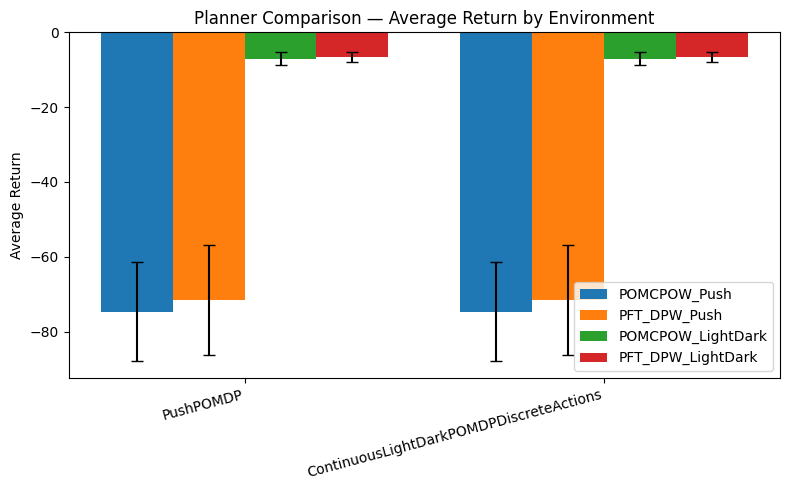

In [8]:
if statistics_df is not None:
    environments = statistics_df["environment"].unique()
    policies = statistics_df["policy"].unique()
    n_envs = len(environments)
    n_policies = len(policies)

    x = np.arange(n_envs)
    bar_width = 0.8 / n_policies

    fig, ax = plt.subplots(figsize=(8, 5))

    for i, policy in enumerate(policies):
        subset = statistics_df[statistics_df["policy"] == policy]
        means = np.asarray(subset["average_return"], dtype=float)
        ci_lower = np.asarray(subset["average_return_ci_lower"], dtype=float)
        ci_upper = np.asarray(subset["average_return_ci_upper"], dtype=float)
        yerr_lower = means - ci_lower
        yerr_upper = ci_upper - means

        offset = (i - (n_policies - 1) / 2) * bar_width
        ax.bar(
            x + offset, means, bar_width,
            yerr=[yerr_lower, yerr_upper], capsize=4,
            label=policy
        )

    ax.set_xticks(x)
    ax.set_xticklabels(environments, rotation=15, ha="right")
    ax.set_ylabel("Average Return")
    ax.set_title("Planner Comparison — Average Return by Environment")
    ax.legend()
    fig.tight_layout()
else:
    print("No statistics to plot.")

## Summary

This notebook demonstrated:

1. **Multi-algorithm comparison** using POMCPOW and PFT-DPW planners
2. **Multi-environment evaluation** across different POMDP domains
3. **Statistical analysis** with confidence intervals and significance testing

The POMDPPlanners framework provides powerful tools for conducting rigorous algorithm comparisons across different problem domains, enabling both statistical rigor and practical insights for algorithm selection and tuning.

**Key Benefits:**
- Standardized evaluation protocols
- Flexible configuration options
- Reproducible experimental workflows

**Next Steps:**
- [Hyperparameter Tuning notebook](hyperparameter_tuning.ipynb)